In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [75]:
def get_normalization_csv():
    """
    this function gets the users CSV file by path,and normalize it at the same time
    saves a copy of the original csv
    """
    ##get the data
    while True:
        file_path = input('Please insert you csv file or path here\n').strip()
        print()
        file_path = file_path.strip('"\'')
        try:
            df = pd.read_csv(file_path)
            df_original = df.copy()
            #dropping every missing data & every columns with id in it.
            df = df.drop(columns=df.filter(regex='(?i)id').columns)
            df = df.dropna()
            
            ##normaliztion of the data
            df = pd.get_dummies(df,drop_first = True,dtype=int)
            scaler = StandardScaler()
            data_scaled = pd.DataFrame(scaler.fit_transform(df), columns = df.columns, index = df.index)
            return df, df_original, data_scaled
        
        except FileNotFoundError:
            print(f"Error: The file '{file_path}' was not found. Please try again.\n")
        except Exception as e:
            print(f"An unexpected error occurred: {e}. Please try again.\n")
            
df, df_original, data_scaled = get_normalization_csv()
print("The normalized DataFrame:")
display(data_scaled)
print('==' *35)
print()
print("The original DataFrame:")
display(df_original)

Please insert you csv file or path here
 "C:\Users\liran\Mall_Customers.csv"



The normalized DataFrame:


,Age,Annual Income,Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405
...,...,...,...,...
195,-0.276302,2.268791,1.118061,-0.886405
196,0.441365,2.497807,-0.861839,-0.886405
197,-0.491602,2.497807,0.923953,1.128152
198,-0.491602,2.917671,-1.250054,1.128152



The original DataFrame:


,CustomerID,Gender,Age,Annual Income,Spending Score (1-100)
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40
...,...,...,...,...,...
195,196,Female,35,120000,79
196,197,Female,45,126000,28
197,198,Male,32,126000,74
198,199,Male,32,137000,18


In [82]:
def get_k():
    """
    Prompts the user to enter valid maximum and minimum K values.
    Returns (user_choice_max, user_choice_min).
    """
    while True:
        try:
            user_choice_min = int(input('Please enter the lowest K: '))
            user_choice_max = int(input('Please enter the highest K: '))
            if user_choice_max <= user_choice_min:
                print('Error - the highest number is lower or equal to the lowest number')
                continue

            return user_choice_max, user_choice_min

        except ValueError:
            print('Error: Invalid input. Please enter numbers only')
            
user_choice_max, user_choice_min = get_k()

Please enter the lowest K:  2
Please enter the highest K:  11


In [29]:
# def normalization(df):
#     df = pd.get_dummies(df,drop_first = True)
#     scaler = StandardScaler()
#     data_scaled = pd.DataFrame(scaler.fit_transform(df), columns = df.columns, index = df.index)
#     return data_scaled
# normalization(df)

,CustomerID,Age,Annual Income,Spending Score (1-100),Gender_Male
0,-1.723412,-1.424569,-1.738999,-0.434801,1.128152
1,-1.706091,-1.281035,-1.738999,1.195704,1.128152
2,-1.688771,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.671450,-1.137502,-1.700830,1.040418,-0.886405
4,-1.654129,-0.563369,-1.662660,-0.395980,-0.886405
...,...,...,...,...,...
195,1.654129,-0.276302,2.268791,1.118061,-0.886405
196,1.671450,0.441365,2.497807,-0.861839,-0.886405
197,1.688771,-0.491602,2.497807,0.923953,1.128152
198,1.706091,-0.491602,2.917671,-1.250054,1.128152


,kmeans,wcss
0,2,588.802677
1,3,476.787554
2,4,388.717861
3,5,331.309884
4,6,276.411760
5,7,236.204947
6,8,199.750461
7,9,174.235477
8,10,152.029834
9,11,137.497372


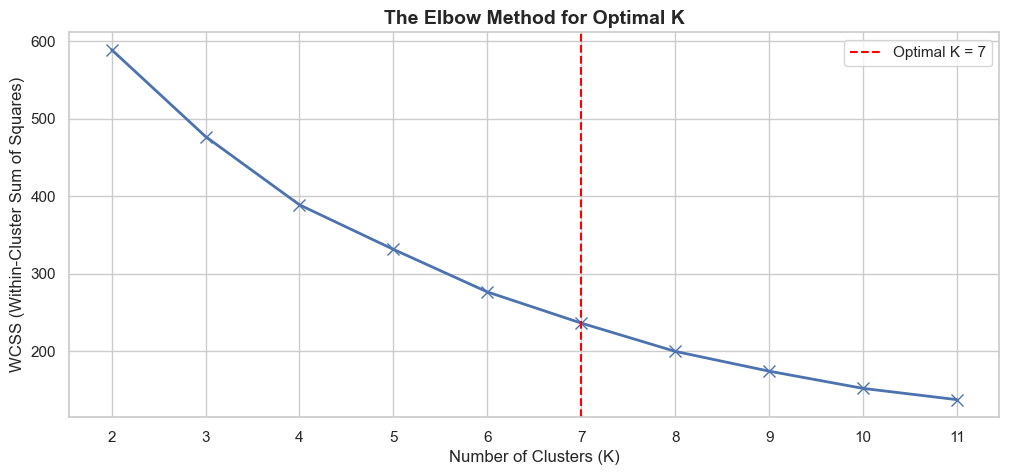

In [83]:
wcss = []

for i in range(user_choice_min, user_choice_max+1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

#saving it as new df
table_kmean_wcss = pd.DataFrame({
    'kmeans': range(user_choice_min, user_choice_max+1),
    'wcss': wcss}) 

display(table_kmean_wcss)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.plot(range(user_choice_min, user_choice_max+1), wcss, 'bx-', linewidth=2, markersize=8)

plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.axvline(
    x=7, color="red", linestyle="--", linewidth=1.5, label="Optimal K = 7")
plt.legend()
plt.xticks(range(user_choice_min, user_choice_max+1))
plt.show()

In [84]:
#test for k
for k in range(user_choice_min, user_choice_max+1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(data_scaled)
    score = silhouette_score(data_scaled, kmeans.labels_)
    print(f"Silhouette Score for K={k}: {score:.4f}")

Silhouette Score for K=2: 0.2518
Silhouette Score for K=3: 0.2595
Silhouette Score for K=4: 0.2984
Silhouette Score for K=5: 0.3041
Silhouette Score for K=6: 0.3311
Silhouette Score for K=7: 0.3574
Silhouette Score for K=8: 0.3880
Silhouette Score for K=9: 0.4031
Silhouette Score for K=10: 0.4208
Silhouette Score for K=11: 0.4275
